# Análise Exploratória da base

Este notebook tem como objetivo explorar uma ou mais bases que irei utilizar para treinar o meu modelo

Baixei as bases desse link: https://www.kaggle.com/datasets/ektarr/counter-strike-pro-matches/data

Irei utilizar as bases abaixo:

cs2_all_tiers_games.csv
cs2_tier1_games.csv
cs2_tier2_games.csv
cs2_tier3_games.csv
players.csv
teams.csv
tournaments.csv

## 1. Importação das bibliotecas

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.stats.proportion import proportion_confint


## 2. Carregamento das bases

In [4]:
all_tiers_games = pd.read_csv("../data/raw/cs2_all_tiers_games.csv")

## 3. Análise descritiva

### 3.1 Estrutura Geral

In [5]:
# Volume de Dados

n_linhas, n_colunas = all_tiers_games.shape
print(f"Volume de Dados: {n_linhas} linhas e {n_colunas} colunas")

Volume de Dados: 20676 linhas e 98 colunas


### 3.2 Informação das colunas

In [6]:
# Nome das colunas

print(all_tiers_games.columns.tolist())

['match_id', 'game_id', 'tournament', 'team1_id', 'team1', 'team2_id', 'team2', 'score1_match', 'score2_match', 'is_total', 'bestOf', 'score1_game', 'score2_game', 'map_id', 'map_name', 'datetime', 'team1_win', 'games_played', 'team1_player1_id', 'team1_player2_id', 'team1_player3_id', 'team1_player4_id', 'team1_player5_id', 'team2_player1_id', 'team2_player2_id', 'team2_player3_id', 'team2_player4_id', 'team2_player5_id', 'team1_player1', 'team1_player2', 'team1_player3', 'team1_player4', 'team1_player5', 'team2_player1', 'team2_player2', 'team2_player3', 'team2_player4', 'team2_player5', 'team1_player1_kills', 'team1_player1_deaths', 'team1_player1_assists', 'team1_player1_adr', 'team1_player1_kast', 'team1_player1_kddiff', 'team1_player2_kills', 'team1_player2_deaths', 'team1_player2_assists', 'team1_player2_adr', 'team1_player2_kast', 'team1_player2_kddiff', 'team1_player3_kills', 'team1_player3_deaths', 'team1_player3_assists', 'team1_player3_adr', 'team1_player3_kast', 'team1_pla

### 3.3 Quantidade de nulos colunas julgadas importantes

In [7]:
# Verificando valores nulos

all_tiers_games[['game_id','bestOf', 'score1_game', 'score2_game','map_name', 'team1_win', 'team1', 'team2', 'datetime']].isnull().sum()

game_id        4750
bestOf          136
score1_game    7077
score2_game    7077
map_name       7126
team1_win         0
team1             1
team2             1
datetime          0
dtype: int64

#### 3.3.1 Por que tantos nulos em map_name?

Pelo que diz no Kaggle, existem dados dos jogos e da série. Por exemplo: se for BO3, teremos uma linha para o primeiro mapa, uma pro segundo, uma pro terceiro (se houver) e uma para o resultado da série.

A hipótese é essa. Abaixo iremos verificar a coluna 'is_total' que pode nos responder caso a quantidade True seja igual ao de nulos no map_name


Conclusão: dos 7126 com map_name nulo, 7048 são linhas que representam o resultado da série e 78 casos são incosistência de dados, como por exemplo match_id = 6908080, onde duas linhas estão trocadas, a do resultado do mapa e resultado da série.

Decisão: Retirar todos os casos onde 'is_total' é nulo, pois assim retiramos todas as linhas de resultado por série e todas as linhas com incosistência nos dados.

In [8]:
# Verificando quais tipos de dados estão presentes na coluna 'is_total'

all_tiers_games['is_total'].unique()

array([False,  True])

In [9]:
# Verificando valores 'is_total' = True

all_tiers_games['is_total'].sum()

np.int64(9923)

In [10]:
# Verificando valores nulos na coluna 'map_name' e 'is_total' = True

all_tiers_games[(all_tiers_games['map_name'].isnull()) & (all_tiers_games['is_total'] == True)]['match_id'].count()

np.int64(7048)

In [11]:
# Verificando valores nulos na coluna 'map_name' e 'is_total' = False

all_tiers_games[(all_tiers_games['map_name'].isnull()) & (all_tiers_games['is_total'] == False)][['match_id', 'game_id', 'tournament', 'team1', 'team2', 'score1_match', 'score2_match', 'is_total', 'bestOf', 'score1_game', 'score2_game', 'map_name', 'team1_win', 'games_played']]

,match_id,game_id,tournament,team1,team2,score1_match,score2_match,is_total,bestOf,score1_game,score2_game,map_name,team1_win,games_played
13,7302975,154178.0,Super DraculaN Season 1,Walczaki,Inner Circle,0.0,2.0,False,3.0,NaN,NaN,NaN,0,2.0
15,7302975,154177.0,Super DraculaN Season 1,Walczaki,Inner Circle,0.0,2.0,False,3.0,NaN,NaN,NaN,0,2.0
16,7302974,154179.0,Super DraculaN Season 1,Acend,Infinite Gaming,2.0,0.0,False,3.0,NaN,NaN,NaN,1,2.0
17,7302974,154180.0,Super DraculaN Season 1,Acend,Infinite Gaming,2.0,0.0,False,3.0,NaN,NaN,NaN,1,2.0
1925,6908080,125742.0,ESL Pro League Season 23,Natus Vincere,FUT Esports,2.0,1.0,False,3.0,NaN,NaN,NaN,0,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19897,684490,116267.0,CBCS Invitational 2023,BESTIA,Case Esports,2.0,0.0,False,3.0,1.0,0.0,NaN,1,2.0
19898,684490,116266.0,CBCS Invitational 2023,BESTIA,Case Esports,2.0,0.0,False,3.0,1.0,0.0,NaN,1,2.0
20247,640014,116055.0,CS2 Asia Championships 2023,TYLOO,Lynn Vision Gaming,1.0,2.0,False,3.0,NaN,NaN,NaN,0,3.0
20359,610310,115994.0,Thunderpick World Championship 2023,Complexity,MOUZ,1.0,2.0,False,3.0,NaN,NaN,NaN,0,3.0


In [12]:
# Verificando caso isolado dos resultados obtidos na celula anterior

all_tiers_games[all_tiers_games['match_id'] == 6279564][['match_id', 'game_id', 'tournament', 'team1', 'team2', 'score1_match', 'score2_match', 'is_total', 'bestOf', 'score1_game', 'score2_game', 'map_name', 'team1_win', 'games_played']]

,match_id,game_id,tournament,team1,team2,score1_match,score2_match,is_total,bestOf,score1_game,score2_game,map_name,team1_win,games_played
2851,6279564,125306.0,IEM Atlanta 2026. Closed Qualifier,Alliance,Johnny Speeds,2.0,0.0,False,3.0,13.0,4.0,NaN,1,2.0
2852,6279564,-125306.0,IEM Atlanta 2026. Closed Qualifier,Alliance,Johnny Speeds,2.0,0.0,True,3.0,0.0,0.0,NaN,0,2.0
2855,6279564,125304.0,IEM Atlanta 2026. Closed Qualifier,Alliance,Johnny Speeds,2.0,0.0,False,3.0,13.0,10.0,NaN,1,2.0


In [13]:
# Retirando os valores onde 'is_total' = True  ou  'map_name' is null

all_tiers_games_individual_maps = all_tiers_games[~((all_tiers_games['is_total'] == True) | (all_tiers_games['map_name'].isnull()) | (all_tiers_games['bestOf'].isnull()))]

all_tiers_games_individual_maps.shape[0]

10656

In [14]:
# Verificando o volume de dados após a filtragem
# Verificando valores nulos

all_tiers_games_individual_maps[['game_id','bestOf', 'score1_game', 'score2_game','map_name', 'team1_win', 'team1', 'team2', 'datetime']].isnull().sum()

game_id        0
bestOf         0
score1_game    0
score2_game    0
map_name       0
team1_win      0
team1          0
team2          0
datetime       0
dtype: int64

### 3.4 Tipos de dados

In [15]:
# Verificando os tipos de dados das colunas do DataFrame filtrado

all_tiers_games_individual_maps[['match_id', 'game_id', 'tournament', 'team1', 'team2', 'score1_match', 'score2_match', 'is_total', 'bestOf', 'score1_game', 'score2_game', 'map_name', 'team1_win', 'games_played', 'datetime']].dtypes

match_id          int64
game_id         float64
tournament          str
team1               str
team2               str
score1_match    float64
score2_match    float64
is_total           bool
bestOf          float64
score1_game     float64
score2_game     float64
map_name            str
team1_win         int64
games_played    float64
datetime            str
dtype: object

In [16]:
# Convertendo a coluna 'datetime' para o tipo datetime

all_tiers_games_individual_maps['datetime'] = pd.to_datetime(all_tiers_games_individual_maps['datetime'], format='%Y-%m-%d %H:%M:%S')

### 3.5 Limite inferior e superior das datas

In [17]:
# Verificando a data mais antiga e mais recente presentes no DataFrame filtrado

all_tiers_games_individual_maps['datetime'].min(), all_tiers_games_individual_maps['datetime'].max()

(Timestamp('2023-10-25 18:00:00'), Timestamp('2026-06-28 20:00:00'))

### 3.6 Quantidade de Mapas

In [18]:
# Listando mapas únicos presentes no DataFrame filtrado

all_tiers_games_individual_maps['map_name'].unique()

<StringArray>
['Overpass',  'Ancient',    'Dust2',   'Mirage',     'Nuke',  'Inferno',
   'Anubis',    'Train',  'Vertigo']
Length: 9, dtype: str

In [19]:
# Verificando quantas vezes cada mapa aparece no DataFrame filtrado

all_tiers_games_individual_maps['map_name'].value_counts()

map_name
Ancient     1849
Mirage      1803
Nuke        1555
Inferno     1371
Dust2       1345
Anubis      1239
Overpass     612
Vertigo      549
Train        333
Name: count, dtype: int64

## 3.7 Quantidade de Times

In [20]:
# Listando times únicos presentes no DataFrame filtrado

teams_1 = all_tiers_games_individual_maps['team1'].unique()
teams_2 = all_tiers_games_individual_maps['team2'].unique()

teams = set(teams_1).union(set(teams_2))

print(f"Times únicos presentes no DataFrame filtrado: {len(teams)}")

Times únicos presentes no DataFrame filtrado: 392


## 3.8 Jogos por time

In [21]:
# Verificando quantas vezes cada time aparece no DataFrame filtrado

team1_counts = all_tiers_games_individual_maps['team1'].value_counts()
team2_counts = all_tiers_games_individual_maps['team2'].value_counts()

team_counts = team1_counts.add(team2_counts, fill_value=0).sort_values(ascending=False)

print(team_counts)

team1
FURIA Esports           481.0
FaZe Clan               475.0
G2 Esports              464.0
Team 3DMAX              452.0
Aurora Gaming           452.0
                        ...  
bombardino crocodilo      1.0
ex-Anonymo Esports        1.0
Zomblers                  1.0
benched                   1.0
vagrants                  1.0
Name: count, Length: 392, dtype: float64


In [22]:
# Traz informações sobre a frequência de jogos de cada time, permitindo identificar os times mais ou menos ativos

low_frequency_teams = team_counts[team_counts < 10]
high_frequency_teams = team_counts[team_counts >= 50]
top_frequency_team = team_counts.idxmax()

print(f"Times com baixa frequência de jogos (menos de 10 jogos): {len(low_frequency_teams)}")
print(f"Times com alta frequência de jogos (50 ou mais jogos): {len(high_frequency_teams)}")
print(f"Time com maior frequência de jogos: {top_frequency_team} ({team_counts.max()} jogos)")

Times com baixa frequência de jogos (menos de 10 jogos): 203
Times com alta frequência de jogos (50 ou mais jogos): 92
Time com maior frequência de jogos: FURIA Esports (481.0 jogos)


## 3.10 Intervalo de confiança para limite inferior de quantidade de jogos

Nessa etapa me questionei qual deveria ser o limite mínimo de jogos que eu deveria considerar para treinar o modelo de forma consistente.

Com a ajuda do Claude, fiz o cálculo do intervalo de confiança abaixo.

Conclusão: A medida que eu aumento o corte, a incerteza vai caindo significativamente, ou seja, não há um jeito fácil de escolher qual corte utilizar. A melhor alternativa é treinar o modelo com esse corte escolhido arbitrariamente e ir testando o desempenho e ir ajustando conforme

faixa_jogos
10-19    0.438179
20-29    0.361200
30-49    0.288572
50-99    0.228067
100+     0.133058
Name: largura_ic, dtype: float64


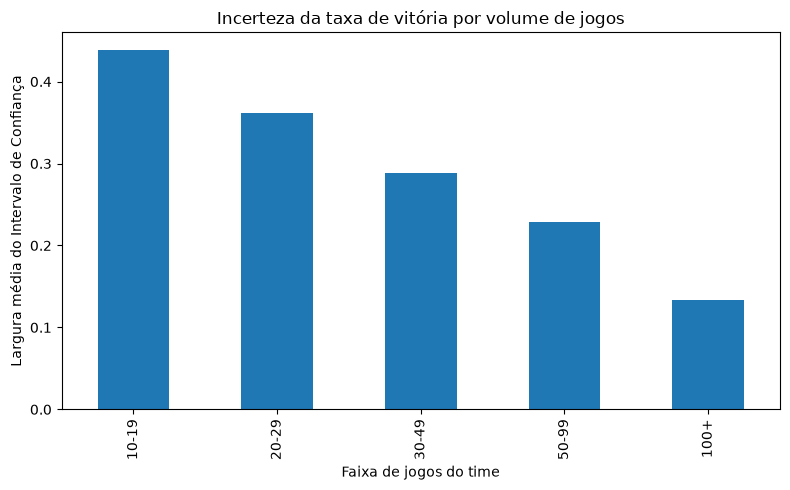

In [23]:

# 1 e 2. Calcula vitórias e total de jogos por time (considerando team1 e team2)
vitorias_team1 = all_tiers_games_individual_maps[all_tiers_games_individual_maps['team1_win'] == 1].groupby('team1').size()
jogos_team1 = all_tiers_games_individual_maps.groupby('team1').size()

vitorias_team2 = all_tiers_games_individual_maps[all_tiers_games_individual_maps['team1_win'] == 0].groupby('team2').size()
jogos_team2 = all_tiers_games_individual_maps.groupby('team2').size()

vitorias_totais = vitorias_team1.add(vitorias_team2, fill_value=0)
jogos_totais = jogos_team1.add(jogos_team2, fill_value=0)

stats_times = pd.DataFrame({
    'jogos': jogos_totais,
    'vitorias': vitorias_totais
})
stats_times['taxa_vitoria'] = stats_times['vitorias'] / stats_times['jogos']

# 3. Calcula o intervalo de confiança de Wilson (95%) para cada time
ic = stats_times.apply(
    lambda row: proportion_confint(row['vitorias'], row['jogos'], alpha=0.05, method='wilson'),
    axis=1
)
stats_times['ic_inferior'] = ic.apply(lambda x: x[0])
stats_times['ic_superior'] = ic.apply(lambda x: x[1])

# 4. Largura do intervalo = medida de incerteza
stats_times['largura_ic'] = stats_times['ic_superior'] - stats_times['ic_inferior']

# 1 (faixas). Agrupa times em faixas de quantidade de jogos
faixas = [10, 20, 30, 50, 100, np.inf]
labels = ['10-19', '20-29', '30-49', '50-99', '100+']
stats_times['faixa_jogos'] = pd.cut(stats_times['jogos'], bins=faixas, labels=labels, right=False)

# 5. Largura média do IC por faixa
largura_por_faixa = stats_times.groupby('faixa_jogos', observed=True)['largura_ic'].mean()
print(largura_por_faixa)

# 6. Visualização
plt.figure(figsize=(8, 5))
largura_por_faixa.plot(kind='bar')
plt.ylabel('Largura média do Intervalo de Confiança')
plt.xlabel('Faixa de jogos do time')
plt.title('Incerteza da taxa de vitória por volume de jogos')
plt.tight_layout()
plt.show()

## 3.10 Filtro pela quantidade de jogos

In [24]:
# Remover equipes com menos de 10 jogos do DataFrame filtrado

all_tiers_games_filtered_by_team_frequency = all_tiers_games_individual_maps.copy()

while True:
    team_counts = pd.concat([all_tiers_games_filtered_by_team_frequency['team1'], all_tiers_games_filtered_by_team_frequency['team2']]).value_counts()
    low_frequency_teams = team_counts[team_counts < 10]
    
    if len(low_frequency_teams) == 0:
        break
    
    all_tiers_games_filtered_by_team_frequency = all_tiers_games_filtered_by_team_frequency[
        ~all_tiers_games_filtered_by_team_frequency['team1'].isin(low_frequency_teams.index) &
        ~all_tiers_games_filtered_by_team_frequency['team2'].isin(low_frequency_teams.index)
    ]
    print(len(low_frequency_teams))

print(f"Linhas finais: {len(all_tiers_games_filtered_by_team_frequency)}")
print(f"Times finais: {all_tiers_games_filtered_by_team_frequency['team1'].nunique() + all_tiers_games_filtered_by_team_frequency['team2'].nunique()}")

203
8
Linhas finais: 9887
Times finais: 356


In [25]:
# Verificar se há registro de jogos registrados mais de uma vez no DataFrame filtrado

all_tiers_games_filtered_by_team_frequency[all_tiers_games_filtered_by_team_frequency.duplicated(keep=False)]

,match_id,game_id,tournament,team1_id,team1,team2_id,team2,score1_match,score2_match,is_total,...,team2_player4_assists,team2_player4_adr,team2_player4_kast,team2_player4_kddiff,team2_player5_kills,team2_player5_deaths,team2_player5_assists,team2_player5_adr,team2_player5_kast,team2_player5_kddiff


In [26]:
# Verificando quantas vezes cada time aparece no DataFrame filtrado

team1_countsx= all_tiers_games_filtered_by_team_frequency['team1'].value_counts()
team2_countsx= all_tiers_games_filtered_by_team_frequency['team2'].value_counts()

team_countsx= team1_countsx.add(team2_countsx, fill_value=0).sort_values(ascending=False)

print(team_countsx)

team1
FURIA Esports    481.0
FaZe Clan        471.0
G2 Esports       462.0
Aurora Gaming    450.0
Team 3DMAX       442.0
                 ...  
ALLINNERS         10.0
Eruption          10.0
GameAgents        10.0
G2 Ares           10.0
PsychoFace        10.0
Name: count, Length: 181, dtype: float64


# 4. Feature Engineering

4.1 Estatísticas por jogador agrupada para o time

Dentro da base, para cada partida temos a estatística individual por jogador de cada time. 
Irei utilizar média de assists, ADR médio, KAST médio e kddiff médio do time por partida.

Aplicarei um método chamado EWMA que adiciona um peso para cada feature mencionada de acordo com a data da partida.
O valor escolhido foi de uma meia-vida de 50% a cada 2,4 meses, tendo em vista a velocidade com que as coisas mudam dentro do cenário do CS.

In [27]:
# Lista as colunas de cada métrica para os 5 jogadores de cada time

# Team1
adr_team1 = [f'team1_player{i}_adr' for i in range(1, 6)]
kast_team1 = [f'team1_player{i}_kast' for i in range(1, 6)]
assists_team1 = [f'team1_player{i}_assists' for i in range(1, 6)]
kddiff_team1 = [f'team1_player{i}_kddiff' for i in range(1, 6)]

# Team 2
adr_team2 = [f'team2_player{i}_adr' for i in range(1, 6)]
kast_team2 = [f'team2_player{i}_kast' for i in range(1, 6)]
assists_team2 = [f'team2_player{i}_assists' for i in range(1, 6)]
kddiff_team2 = [f'team2_player{i}_kddiff' for i in range(1, 6)]


In [28]:
# Cálculo da média das métricas de cada jogador de cada time para cada jogo, criando novas colunas no DataFrame filtrado

# Team 1
all_tiers_games_filtered_by_team_frequency['team1_avg_adr'] = all_tiers_games_filtered_by_team_frequency[adr_team1].mean(axis=1)
all_tiers_games_filtered_by_team_frequency['team1_avg_kast'] = all_tiers_games_filtered_by_team_frequency[kast_team1].mean(axis=1)
all_tiers_games_filtered_by_team_frequency['team1_avg_assists'] = all_tiers_games_filtered_by_team_frequency[assists_team1].mean(axis=1)
all_tiers_games_filtered_by_team_frequency['team1_avg_kddiff'] = all_tiers_games_filtered_by_team_frequency[kddiff_team1].mean(axis=1)

# Team 2
all_tiers_games_filtered_by_team_frequency['team2_avg_adr'] = all_tiers_games_filtered_by_team_frequency[adr_team2].mean(axis=1)
all_tiers_games_filtered_by_team_frequency['team2_avg_kast'] = all_tiers_games_filtered_by_team_frequency[kast_team2].mean(axis=1)
all_tiers_games_filtered_by_team_frequency['team2_avg_assists'] = all_tiers_games_filtered_by_team_frequency[assists_team2].mean(axis=1)
all_tiers_games_filtered_by_team_frequency['team2_avg_kddiff'] = all_tiers_games_filtered_by_team_frequency[kddiff_team2].mean(axis=1)


In [32]:
# Criar subset do DataFrame filtrado com as colunas de interesse para análise exploratória

# Team 1
team1_vision = pd.DataFrame({
'team': all_tiers_games_filtered_by_team_frequency['team1'],
'adversary': all_tiers_games_filtered_by_team_frequency['team2'],
'datetime': all_tiers_games_filtered_by_team_frequency['datetime'],
'map_name': all_tiers_games_filtered_by_team_frequency['map_name'],
'match_id': all_tiers_games_filtered_by_team_frequency['match_id'],
'game_id': all_tiers_games_filtered_by_team_frequency['game_id'],
'adr': all_tiers_games_filtered_by_team_frequency['team1_avg_adr'],
'kast': all_tiers_games_filtered_by_team_frequency['team1_avg_kast'],
'assists': all_tiers_games_filtered_by_team_frequency['team1_avg_assists'],
'kddiff': all_tiers_games_filtered_by_team_frequency['team1_avg_kddiff'],

# Se team1_win = 1, então o time venceu, caso contrário, perdeu
'team_win': (all_tiers_games_filtered_by_team_frequency['team1_win'] == 1).astype(int)
})

# Team 2
team2_vision = pd.DataFrame({
'team': all_tiers_games_filtered_by_team_frequency['team2'],
'adversary': all_tiers_games_filtered_by_team_frequency['team1'],
'datetime': all_tiers_games_filtered_by_team_frequency['datetime'],
'map_name': all_tiers_games_filtered_by_team_frequency['map_name'],
'match_id': all_tiers_games_filtered_by_team_frequency['match_id'],
'game_id': all_tiers_games_filtered_by_team_frequency['game_id'],
'adr': all_tiers_games_filtered_by_team_frequency['team2_avg_adr'],
'kast': all_tiers_games_filtered_by_team_frequency['team2_avg_kast'],
'assists': all_tiers_games_filtered_by_team_frequency['team2_avg_assists'],
'kddiff': all_tiers_games_filtered_by_team_frequency['team2_avg_kddiff'],

# Se team1_win = 0, então o time venceu, caso contrário, perdeu

'team_win': (all_tiers_games_filtered_by_team_frequency['team1_win'] == 0).astype(int)
})

In [33]:
# Concatenar os dois DataFrames para criar um único DataFrame com a visão de cada time

all_tiers_games_team_vision = pd.concat([team1_vision, team2_vision], ignore_index=True)

In [35]:
# Verificar se all_tiers_games_team_vision tem o dobro de linhas de all_tiers_games_filtered_by_team_frequency

print(f"Linhas em all_tiers_games_filtered_by_team_frequency: {len(all_tiers_games_filtered_by_team_frequency)}")
print(f"Linhas em all_tiers_games_team_vision: {len(all_tiers_games_team_vision)}")
print(f"Deve ser o dobro: {len(all_tiers_games_filtered_by_team_frequency) * 2 == len(all_tiers_games_team_vision)}")

Linhas em all_tiers_games_filtered_by_team_frequency: 9887
Linhas em all_tiers_games_team_vision: 19774
Deve ser o dobro: True


In [46]:
# Ordenar o dataframe por team e datetime para garantir que os registros estejam na ordem correta

all_tiers_games_team_vision = all_tiers_games_team_vision.sort_values(by=['team', 'datetime'], ascending=[True, True])


In [47]:
# Aplicar EWMA para cada time, considerando a média das métricas de cada jogador de cada time para cada jogo, criando novas colunas no DataFrame filtrado

def calcular_ewma(grupo, coluna):
    return grupo[coluna].ewm(halflife='72D', times=grupo['datetime'], adjust=True).mean()

metricas = ['adr', 'kast', 'assists', 'kddiff']

for metrica in metricas:
    all_tiers_games_team_vision[f'{metrica}_ewma'] = (
        all_tiers_games_team_vision.groupby('team')
        .apply(lambda grupo: calcular_ewma(grupo, metrica))
        .reset_index(level=0, drop=True)
    )

In [77]:
all_tiers_games_team_vision[all_tiers_games_team_vision['adr_ewma'].isnull() == True]

,team,adversary,datetime,map_name,match_id,game_id,adr,kast,assists,kddiff,team_win,adr_ewma,kast_ewma,assists_ewma,kddiff_ewma
13113,Oxuji Esports,ALLINNERS,2025-12-09 18:15:00,Dust2,5771030,124879.0,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN,NaN
13114,Oxuji Esports,ALLINNERS,2025-12-09 18:15:00,Ancient,5771030,124878.0,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN,NaN
13115,Oxuji Esports,Nemiga Gaming,2026-02-01 13:35:00,Nuke,6155009,125211.0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN
13116,Oxuji Esports,Nemiga Gaming,2026-02-01 13:35:00,Anubis,6155009,125210.0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN
13117,Oxuji Esports,Nuclear TigeRES,2026-02-15 15:45:00,Ancient,6359492,125369.0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN
13118,Oxuji Esports,Nuclear TigeRES,2026-02-15 15:45:00,Inferno,6359492,125370.0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN
14128,RUSH B,SAW,2024-02-26 22:00:00,Nuke,917106,117027.0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN
14129,RUSH B,SAW,2024-02-26 22:00:00,Vertigo,917106,117026.0,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN,NaN
14822,Sashi Esport,ENTERPRISE esports,2024-04-11 12:00:00,Inferno,1075787,117662.0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN
14823,Sashi Esport,ENTERPRISE esports,2024-04-11 12:00:00,Nuke,1075787,117661.0,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN,NaN
